# Частинка у магнітному полі

### 1. Перший закон Ньютона 
$\dot{\vec{v}}=\dfrac{e}{m}\left[\vec{E} + [\vec{v}\times\vec{B}]\right]$

### 2. Усі операції лінійні:
$\dot{\vec{v_\perp}}=\dfrac{e}{m}\left[\vec{E_\perp} + [\vec{v_\perp}\times\vec{B}]\right]$

$\dot{\vec{v_\parallel}}=\dfrac{e}{m}\left[\vec{E_\parallel} + [\vec{v_\parallel}\times\vec{B}]\right]$

### 3. Вибір системи координат
$\dot{\vec{v}}_{\perp}=\dfrac{e}{m}\left[\vec{E_\perp} + \begin{pmatrix}
0 & B \\
-B & 0
\end{pmatrix}\vec{v_\perp}\right]$

$\dot{\vec{v_\parallel}}=\dfrac{e}{m}\vec{E_z}$





### 4. Розв'язок дифрівняння і деякі шененіганси з ним
$A(\phi) = \begin{pmatrix}
\cos{\phi} & \sin{\phi} \\
-\sin{\phi} & \cos{\phi}
\end{pmatrix}$


$K(t) = \dfrac{1}{\omega}A(-\omega t - \dfrac{\pi}{2})$

$\omega = \dfrac{e}{m}B$

$V = \dfrac{1}{B}\begin{pmatrix}
E_y \\
-E_x 
\end{pmatrix}$


#### Фінальне рівняння
$r_xy = \dfrac{1}{\omega}A(-\omega t - \dfrac{\pi}{2})(v_{0\perp} - V) + V t$

$(x,y) = K(t)(v_{0\perp} - V) + V t$

$z = v_{0z} t  + \dfrac{e}{2m}E_z t^2$

In [1]:
%matplotlib widget
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

Початкові умови

In [2]:
e = 1
m = 1
Ex, Ey, Ez = 1, 1, 1
B = 1
vox, voy, voz = 1, 2, 3

Допоміжні функції та змінні

In [3]:
omega = e / m * B
vop = np.array([vox, voy])
V = np.array([Ey, -Ex]) / B

In [4]:
def A(phi):
    return np.array([
        [np.cos(phi), np.sin(phi)],
        [-np.sin(phi), np.cos(phi)]])

def K(t):
    return 1 / omega * A(-omega *  t - np.pi / 2)


Функція радіус-вектора

In [5]:
def rp(t):
    return K(t) @ (vop - V) + V*t

def z(t):
    return voz * t + e / 2 / m * Ez *  t**2

def r(t):
    return np.array([*rp(t), z])

## Створення анімації

In [6]:
dt = 0.1
timespan = np.arange(0, 10, dt)

/home/alex/labs/venv/lib/python3.13/site-packages/matplotlib/animation.py:908: UserWarning: Animation was deleted without rendering anything. This is most likely not intended. To prevent deletion, assign the Animation to a variable, e.g. `anim`, that exists until you output the Animation using `plt.show()` or `anim.save()`.
  warnings.warn(


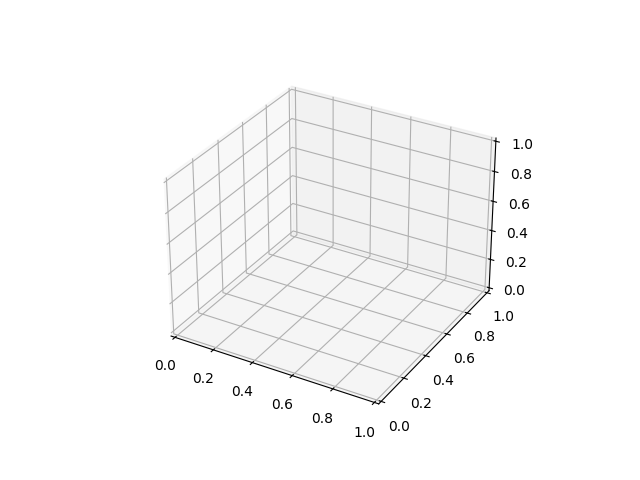

In [8]:
fig = plt.figure()
ax1 = fig.add_subplot(111, projection='3d')
traj1, = ax1.plot([],[],[], '-b')
pos1, = ax1.plot([],[],[], marker='o')# ax1.scatter(x1(0), y1(0), '+r')


def animate(t_max):
    times = timespan[:int(t_max/dt)]
    traj1.set_data([r(t)[0] for t in times], [r(t)[1] for t in times], [r(t)[2] for t in times])
    pos1.set_data([r(t_tax)[0]], [r(t_max)[1]], [r(t_max)[2]])
anim_running = True

def onClick(event):
    global anim_running
    if anim_running:
        ani.event_source.stop()
        anim_running = False
    else:
        ani.event_source.start()
        anim_running = True


def init():
    # 
    # ax1.set_ylim(-5, 30)
    # ax1.set_xlim(-20, 5)
    # ax1.axhline(0, color='black', lw=1)
    # ax1.axvline(0, color='black', lw=1)

    plt.rcParams.update({'font.size': 10})

    return traj1


ani = FuncAnimation(fig, animate, timespan, init_func=init, interval=50, blit=True,)
fig.canvas.mpl_connect('button_press_event', onClick)

plt.show()

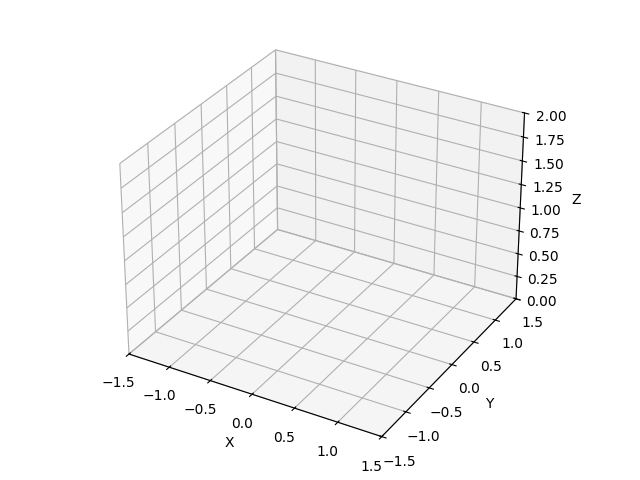

In [9]:

%matplotlib widget
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # Required for 3D projection
from matplotlib.animation import FuncAnimation

# === Dummy functions for demo ===
# Replace with your real functions and time array
def r(t):  # 3D helix path for example
    return np.array([np.cos(t), np.sin(t), 0.1 * t])

dt = 0.05
t_end = 20
timespan = np.arange(0, t_end, dt)

# === Set up 3D plot ===
fig = plt.figure()
ax1 = fig.add_subplot(111, projection='3d')

# Initial line and point
traj1, = ax1.plot([], [], [], '-b', lw=2)
pos1, = ax1.plot([], [], [], 'or')

# === Set plot limits ===
ax1.set_xlim(-1.5, 1.5)
ax1.set_ylim(-1.5, 1.5)
ax1.set_zlim(0, t_end * 0.1)
ax1.set_xlabel("X")
ax1.set_ylabel("Y")
ax1.set_zlabel("Z")

# === Animation function ===
def animate(i):
    t_max = timespan[i]
    times = timespan[:i]
    xs = [r(t)[0] for t in times]
    ys = [r(t)[1] for t in times]
    zs = [r(t)[2] for t in times]

    traj1.set_data(xs, ys)
    traj1.set_3d_properties(zs)

    pos = r(t_max)
    pos1.set_data([pos[0]], [pos[1]])
    pos1.set_3d_properties([pos[2]])

    return traj1, pos1

# === Toggle play/pause on click ===
anim_running = True
def onClick(event):
    global anim_running
    if anim_running:
        ani.event_source.stop()
    else:
        ani.event_source.start()
    anim_running = not anim_running

fig.canvas.mpl_connect('button_press_event', onClick)

# === Init function ===
def init():
    traj1.set_data([], [])
    traj1.set_3d_properties([])
    pos1.set_data([], [])
    pos1.set_3d_properties([])
    return traj1, pos1

# === Launch animation ===
ani = FuncAnimation(
    fig, animate, frames=len(timespan), init_func=init,
    interval=30, blit=True
)

plt.tight_layout()
plt.show()